# Hand classifier (MobileNet Finetuned)
This model uses a pretrained model with most weights frozen and only trains the upper layers.  

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

C:\Users\Omistaja\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


tensorflow


In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 4
img_size = (224, 224)

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    'images/train',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    validation_split=0.177, # ensures validation and test sets are equal size
    subset='both',
    shuffle=True,
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    'images/test',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    shuffle=False)

Found 255 files belonging to 5 classes.
Using 210 files for training.
Using 45 files for validation.
Found 45 files belonging to 5 classes.


## Building the model
The pretrained models tested with this dataset were VGG16 and MobileNetV2.  
MobileNetV2 was chosen as the final model because it achieved slightly better results.

In [3]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
from keras import Sequential
from keras import layers
from keras.optimizers import Adam
num_classes = 5

conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# freeze all training
conv_base.trainable = False

In [4]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [5]:
from keras.optimizers import Adam
inputs = layers.Input(shape=(224, 224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = conv_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
model.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="feature_extraction.keras",
        save_best_only=True,
        monitor="val_loss",
    )
]

history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=validation_dataset,
    callbacks=callbacks,
)

Epoch 1/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2619 - loss: 1.9202 - val_accuracy: 0.4889 - val_loss: 1.3138
Epoch 2/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4476 - loss: 1.2868 - val_accuracy: 0.2667 - val_loss: 1.5368
Epoch 3/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4762 - loss: 1.2250 - val_accuracy: 0.5111 - val_loss: 1.1898
Epoch 4/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5429 - loss: 1.0674 - val_accuracy: 0.5778 - val_loss: 0.9952
Epoch 5/5
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5857 - loss: 1.0108 - val_accuracy: 0.5333 - val_loss: 1.0279


In [8]:
conv_base.trainable = True

for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
for layer in conv_base.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])    

In [9]:
from keras.callbacks import EarlyStopping

finetuned_history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=validation_dataset,
    callbacks=[
        EarlyStopping(patience=3, restore_best_weights=True)
    ]
)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.4476 - loss: 1.3984 - val_accuracy: 0.6222 - val_loss: 0.9733
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4714 - loss: 1.2755 - val_accuracy: 0.5778 - val_loss: 0.9575
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5143 - loss: 1.1651 - val_accuracy: 0.6000 - val_loss: 0.9391
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5333 - loss: 1.1523 - val_accuracy: 0.6000 - val_loss: 0.9278
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5286 - loss: 1.1101 - val_accuracy: 0.6222 - val_loss: 0.9200
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5143 - loss: 1.1409 - val_accuracy: 0.6222 - val_loss: 0.9122
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5619 - loss: 1.0443 - val_accuracy: 0.5778 - val_loss: 0.9112
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.5714 - loss: 0.9932 - val_accuracy: 0.5778 - v

In [10]:
images = []
labels = []
class_names = ['1 finger', '2 fingers', '3 fingers', '4 fingers', '5 fingers']

for image_batch, label_batch in test_dataset:
    images.append(image_batch.numpy())
    labels.append(label_batch.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

In [11]:
def show_example_images_and_predictions(predicted_labels):
    plt.figure(figsize=(15, 8))
    
    for i in range(20):
        plt.subplot(4, 5, i + 1)
    
        plt.imshow(images[i].astype("uint8"))
    
        true_label = y_true_classes[i]
        pred_label = predicted_labels[i]
    
        color = "green" if true_label == pred_label else "red"
    
        plt.title(
            f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}",
            color=color
        )
    
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

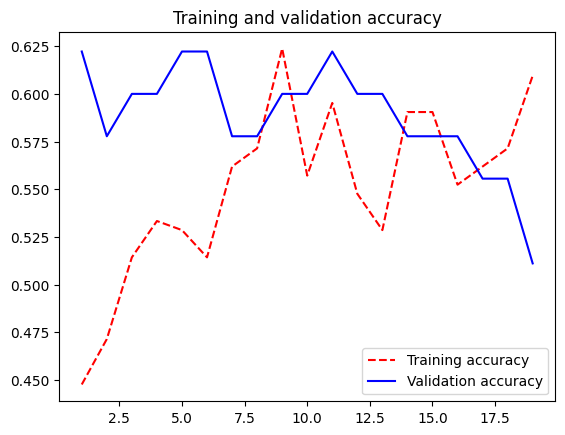

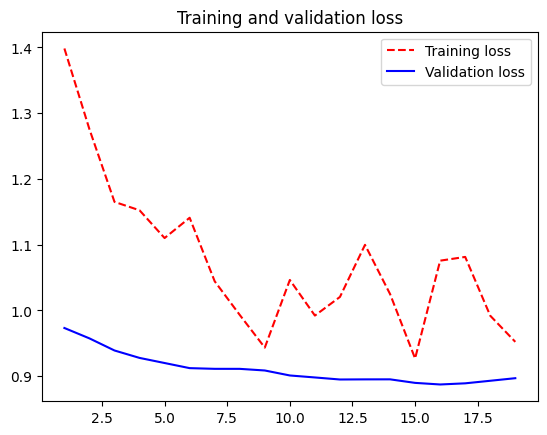

In [12]:
acc = finetuned_history.history["accuracy"]
val_acc = finetuned_history.history["val_accuracy"]
loss = finetuned_history.history["loss"]
val_loss = finetuned_history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [13]:
loss, acc = model.evaluate(test_dataset, verbose=0)
print(f"The model's test accuracy is {acc}")

The model's test accuracy is 0.4888888895511627


The model has achieved an accuracy that fluctuates around 45-51%, which is barely above making wild guesses.  
It performs significantly worse than the baseline CNN model that achieved a maximum accuracy of 71%.  
Interestingly, the finetuning has made this model even worse than the base MobileNetV2.

In [14]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.concatenate([y for x, y in test_dataset], axis=0)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


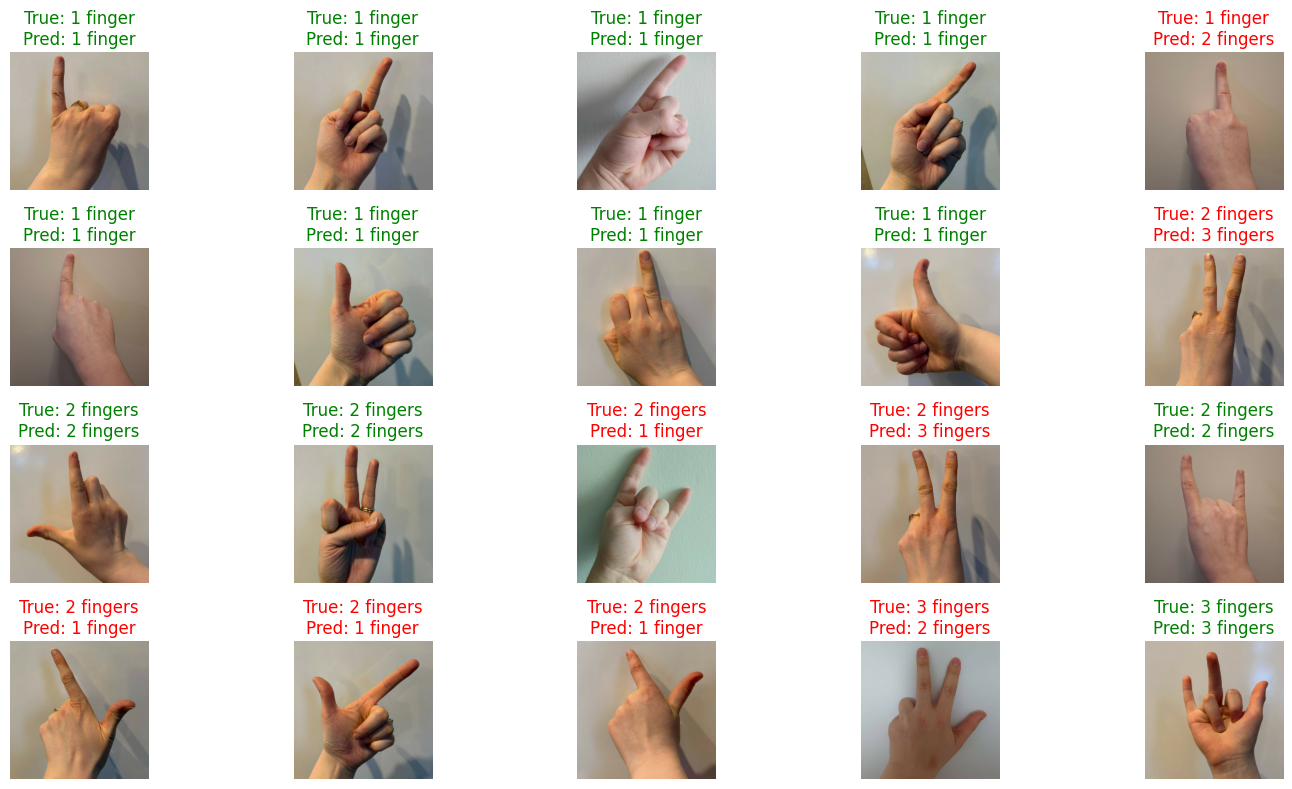

In [15]:
y_pred = model.predict(test_dataset)
y_pred_classes = np.argmax(y_pred, axis=1)
show_example_images_and_predictions(y_pred_classes)